In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import h5py

from sklearn.metrics import f1_score, roc_auc_score, roc_curve

In [2]:
# use latex
plt.rc('text', usetex=True)
# set font size
plt.rc('font', size=14)

In [39]:
num_augment = 1000
num_mut = 50

path_db = f"../experiments/datasets/RR/data_augmentation/x{num_augment}-{num_mut}_mut/"

In [40]:
from sklearn.preprocessing import label_binarize

def compute_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)
    return fpr, tpr, roc_auc

def multiclass_average_roc(y_true, y_probs, classes=None, num_interp_points=100):
    """
    Computes the average ROC curve and AUC score for multiclass classification.
    
    Parameters:
        y_true (array-like): True labels (shape: [n_samples])
        y_probs (array-like): Predicted probabilities (shape: [n_samples, n_classes])
        classes (array-like, optional): List of all class labels. If None, inferred from y_true.
        num_interp_points (int): number of intepolants.
        
    Returns:
        fpr (np.ndarray): np.linspace(0, 1, num_interp_points)
        tpr (np.ndarray): Mean true positive rates (averaged across classes).
        auc (float): Mean AUC score across classes.
    """
    if classes is None:
        classes = np.unique(y_true)
    y_true_bin = label_binarize(y_true, classes=classes)
    
    fpr = np.linspace(0, 1, num_interp_points)
    tpr = dict()
    roc_auc = dict()
    for i, c in enumerate(classes):
        fpr_class, tpr_class, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[c] = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
        tpr[c] = np.interp(fpr, fpr_class, tpr_class)
    
    mean_tpr = np.vstack([tpr[c] for c in classes]).mean(0)
    mean_auc = np.array([roc_auc[c] for c in classes]).mean()
    
    return fpr, mean_tpr, mean_auc

In [41]:
roc_curves_data_augmented = {f"seed_{i+1}": {} for i in range(10)}
roc_curves_data_baseline = {f"seed_{i+1}": {} for i in range(10)}

for filename in os.listdir(path_db):
    if "predictions" not in filename:
        continue
    print("processing file:", filename)
    key = "seed_" + filename.split(".")[-3].split("_")[-1]
    results_dict = {}
    with h5py.File(os.path.join(path_db, filename), "r") as data:
        # Convert bytes back to strings for labels
        y_true = data["labels_true"][()].astype(str)
        y_prob = data["predictions"]["logreg"]["labels_probs"][()]
        fpr, tpr, roc_auc = multiclass_average_roc(y_true, y_prob)
        results_dict["fpr"] = fpr
        results_dict["tpr"] = tpr
        results_dict["roc_auc"] = roc_auc
    if "augmented" in filename:
        roc_curves_data_augmented[key] = results_dict
    else:
        roc_curves_data_baseline[key] = results_dict

processing file: seed_1.test.rbm.baseline_seed_1.predictions.h5
processing file: seed_1.test.rbm.augmented_seed_1.predictions.h5
processing file: seed_2.test.rbm.baseline_seed_2.predictions.h5
processing file: seed_2.test.rbm.augmented_seed_2.predictions.h5
processing file: seed_3.test.rbm.baseline_seed_3.predictions.h5
processing file: seed_3.test.rbm.augmented_seed_3.predictions.h5
processing file: seed_4.test.rbm.baseline_seed_4.predictions.h5
processing file: seed_4.test.rbm.augmented_seed_4.predictions.h5
processing file: seed_5.test.rbm.baseline_seed_5.predictions.h5
processing file: seed_5.test.rbm.augmented_seed_5.predictions.h5
processing file: seed_6.test.rbm.baseline_seed_6.predictions.h5
processing file: seed_6.test.rbm.augmented_seed_6.predictions.h5
processing file: seed_7.test.rbm.baseline_seed_7.predictions.h5
processing file: seed_7.test.rbm.augmented_seed_7.predictions.h5
processing file: seed_8.test.rbm.baseline_seed_8.predictions.h5
processing file: seed_8.test.rbm.

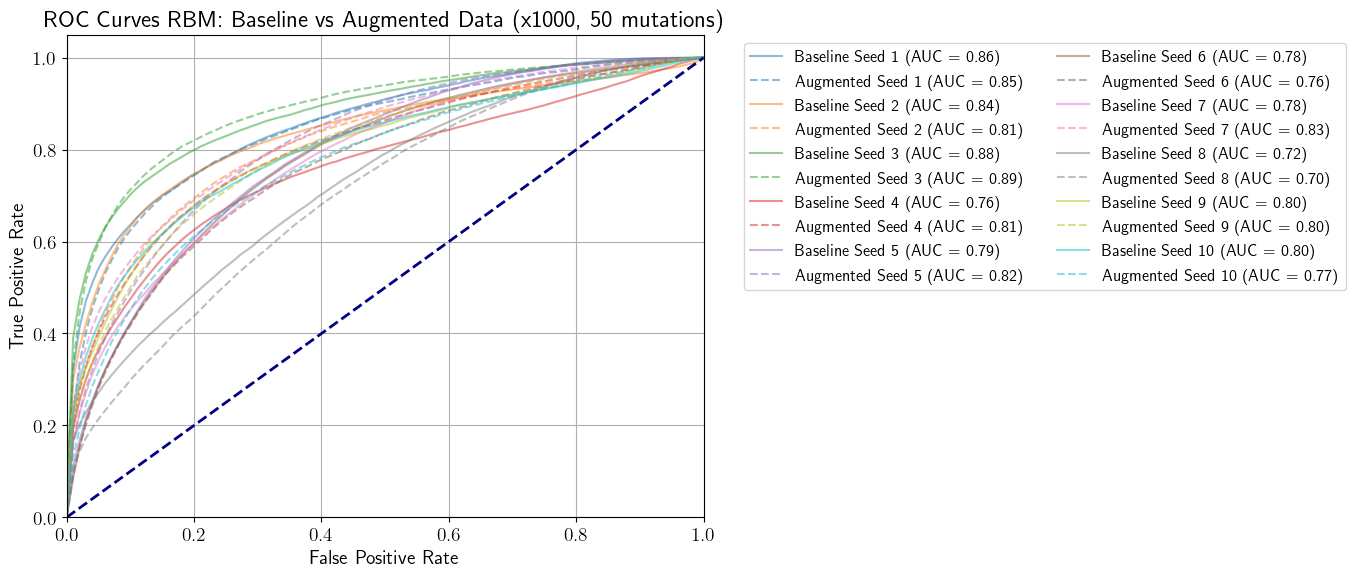

In [42]:
# Plot in solid line the baseline and in dashed line the augmented
plt.figure(figsize=(14, 6))
for seed in range(1, 10+1):
    color = sns.color_palette("tab10")[seed-1]
    plt.plot(roc_curves_data_baseline[f"seed_{seed}"]["fpr"], 
             roc_curves_data_baseline[f"seed_{seed}"]["tpr"], 
             linestyle='-', alpha=0.5, label=f'Baseline Seed {seed} (AUC = {roc_curves_data_baseline[f"seed_{seed}"]["roc_auc"]:.2f})', color=color)
    plt.plot(roc_curves_data_augmented[f"seed_{seed}"]["fpr"], 
             roc_curves_data_augmented[f"seed_{seed}"]["tpr"], 
             linestyle='--', alpha=0.5, label=f'Augmented Seed {seed} (AUC = {roc_curves_data_augmented[f"seed_{seed}"]["roc_auc"]:.2f})', color=color)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves RBM: Baseline vs Augmented Data (x{num_augment}, {num_mut} mutations)')
plt.legend(loc="upper left", fontsize='small', ncol=2, bbox_to_anchor=(1.05, 1))
plt.grid()
plt.tight_layout()

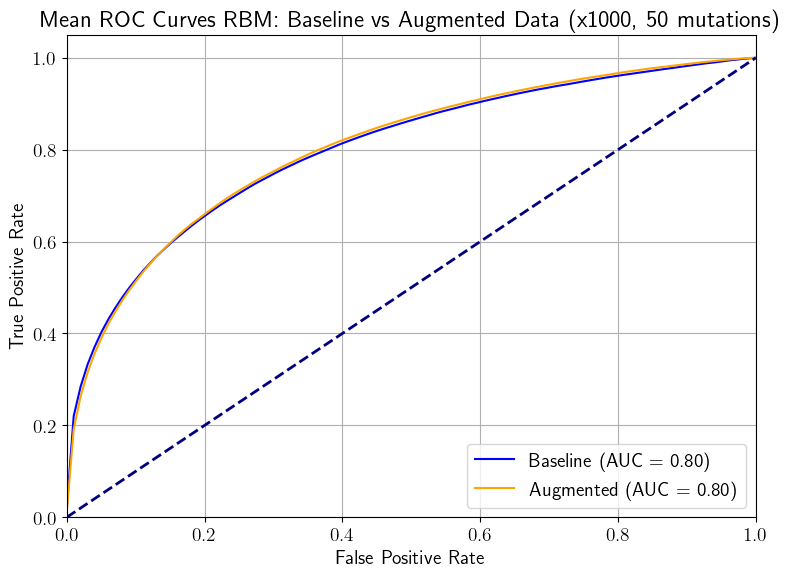

In [43]:
# plot the mean ROC curves
plt.figure(figsize=(8, 6))
# Baseline
fpr_base, tpr_base, auc_base = np.mean([list(roc_curves_data_baseline[f"seed_{i+1}"]["fpr"]) for i in range(10)], axis=0), \
                               np.mean([list(roc_curves_data_baseline[f"seed_{i+1}"]["tpr"]) for i in range(10)], axis=0), \
                               np.mean([roc_curves_data_baseline[f"seed_{i+1}"]["roc_auc"] for i in range(10)])
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {auc_base:.2f})', color='blue')
# Augmented
fpr_aug, tpr_aug, auc_aug = np.mean([list(roc_curves_data_augmented[f"seed_{i+1}"]["fpr"]) for i in range(10)], axis=0), \
                               np.mean([list(roc_curves_data_augmented[f"seed_{i+1}"]["tpr"]) for i in range(10)], axis=0), \
                               np.mean([roc_curves_data_augmented[f"seed_{i+1}"]["roc_auc"] for i in range(10)])
plt.plot(fpr_aug, tpr_aug, label=f'Augmented (AUC = {auc_aug:.2f})', color='orange')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Mean ROC Curves RBM: Baseline vs Augmented Data (x{num_augment}, {num_mut} mutations)')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()